# DAGMA — Analisis cruzado de fuentes

In [1]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import openpyxl

import matplotlib.pyplot as plt

In [2]:
SEED = 42
RAIZ = Path.cwd().resolve()
while not (RAIZ / ".git").exists():
    RAIZ = RAIZ.parent

RUTA_DAGMA = RAIZ / "dagma"
RUTA_CSV = RAIZ / "csv"

PARQUET = RUTA_DAGMA / "dagma_cvc_horario_raw.parquet"
XLSX = RUTA_DAGMA / "dagma-cristian.xlsx"
METADATA_ESTACIONES = RUTA_DAGMA / "estaciones_metadata.csv"

CONTAMINANTES = ["NO2", "SO2", "O3"]

MAPEO_ESTACIONES = {
    "BASE AÉREA": "Base Aerea",
    "CAÑAVERALEJO": "Canaveralejo",
    "COMPARTIR": "Compartir",
    "ERA OBRERO": "ERA - Obrero",
    "ESTACIÓN YUMBO": None,
    "LA ERMITA": "Ermita",
    "LA FLORA": "Flora",
    "PANCE": "Pance",
    "TRANSITORIA-NAVARRO": "Transitoria - Navarro",
    "UNIVERSIDAD DEL VALLE": "Univalle",
}

CONTAMINANTES_EXTRA = ["PM25", "PM10", "H2S", "Black Carbon"]
METEOROLOGIA = ["Temperatura", "Humedad", "Vel Viento", "Dir Viento", "Lluvia", "Radiacion Solar", "Presion Baromet"]

## Estaciones

In [3]:
estaciones = pd.read_csv(METADATA_ESTACIONES)
print(f"Estaciones: {len(estaciones)}")

Estaciones: 10


## Parquet principal

In [4]:
pq = pd.read_parquet(PARQUET)
print(f"Shape: {pq.shape}")

Shape: (107291, 14)


In [5]:
print(pq.groupby(["nombre_est", "msfl_code"]).size().unstack(fill_value=0).to_string())

msfl_code               NO2     O3    SO2
nombre_est                               
BASE AÉREA                0   7310   7770
CAÑAVERALEJO              0      0   5053
COMPARTIR                 0   7507      0
ERA OBRERO                0   6939      0
ESTACIÓN YUMBO         6246  16091  12035
LA ERMITA                 0      0   8627
LA FLORA                  0   5902   4165
PANCE                     0   5861      0
TRANSITORIA-NAVARRO       0   4138   3297
UNIVERSIDAD DEL VALLE     0   6350      0


## Excel SVCASC

In [6]:
xls = pd.read_excel(XLSX, sheet_name="SVCASC.(2015-2020)", header=[22, 23])
xls = xls.iloc[1:].reset_index(drop=True)
flat_cols = ["fecha"]
for i, col in enumerate(xls.columns):
    if i > 0:
        parts = [str(c).strip() for c in col if pd.notna(c) and str(c).strip()]
        flat_cols.append("_".join(parts))
xls.columns = flat_cols
xls["fecha"] = pd.to_datetime(xls["fecha"], format="%d/%m/%Y %H:%M", errors="coerce")
xls = xls.dropna(subset=["fecha"]).reset_index(drop=True)
for c in xls.columns:
    if c != "fecha":
        xls[c] = pd.to_numeric(xls[c], errors="coerce")

In [7]:
xl = xls.melt(id_vars=["fecha"], var_name="columna", value_name="valor")
xl = xl.dropna(subset=["valor"]).reset_index(drop=True)
xl["estacion"] = xl["columna"].str.split("_", n=1).str[0]
xl["variable"] = xl["columna"].str.split("_", n=1).str[1]

## Explorar antes de limpiar

In [8]:
print("Estaciones:", xl["estacion"].value_counts().to_string())

Estaciones: estacion
Compartir                429934
Pance                    306931
Flora                    269421
ERA - Obrero             220180
Canaveralejo             196592
Univalle                 194753
Ermita                   157609
Transitoria - Navarro    106019
Base Aerea                94326
Base Aérea                38373


In [9]:
print(xl[xl["variable"].isin(["NO2","SO2","O3","PM25","PM10"])].groupby(["estacion","variable"]).size().unstack(fill_value=0).to_string())

variable                 NO2     O3   PM10   PM25    SO2
estacion                                                
Base Aerea                 0  32998      0  34068  27260
Canaveralejo               0      0  41194   4198  37704
Compartir                  0  39918  40030  37851      0
ERA - Obrero               0  32218  40506   6155      0
Ermita                     0      0  43733   4704  41787
Flora                      0  30178  40355   5972  29053
Pance                      0  40857  41809   4202      0
Transitoria - Navarro      0   6761  34466   4176  14829
Univalle               25158  38198   2722  39320      0


In [10]:
print(xl.groupby("variable").agg(n=("valor","count"),neg=("valor",lambda x:(x<0).sum()),media=("valor","mean"),min=("valor","min"),max=("valor","max")).to_string())

                           n  neg        media          min            max
variable                                                                  
Black Carbon           10447    0  3309.781783      0.62000  893897.500000
Dir Viento            137600    0   177.745405      0.00000     360.000000
H2S                    79773    0     2.247921      0.00000      74.892059
Humedad               156848    0    66.646648      7.10000     100.000000
Lluvia                242327   75     1.451103 -10807.27000    1611.870000
NO2                    25158    0    13.970609      0.00000      91.857945
O3                    221128    0    28.858265      0.00000     404.175964
PM10                  284815    0    43.225186      0.00000     420.000000
PM25                  140646    0    17.646578      0.00000     388.000000
Presion Baromet        98180    0   819.965663    673.90000     912.500000
Presion Baromet _NEF    7881    0   901.971526    880.30000     908.600000
Radiacion Solar       149

## Limpiar Excel

In [11]:
xl["estacion"] = xl["estacion"].str.normalize("NFKD").str.encode("ascii", errors="ignore").str.decode("ascii")
xl["columna"] = xl["columna"].str.normalize("NFKD").str.encode("ascii", errors="ignore").str.decode("ascii")
xl = xl[xl["variable"] != "Presion Baromet _NEF"]
xl = xl[xl["variable"] != "UV-PM"]
xl = xl[xl["valor"] >= 0]
xl = xl.reset_index(drop=True)
print(f"Shape tras limpieza: {xl.shape}")

Shape tras limpieza: (2001365, 5)


In [12]:
OUT = RAIZ / "csv"
OUT.mkdir(parents=True, exist_ok=True)
xl.to_csv(OUT / "dagma_excel_limpio.csv", index=False)
print(f"Exportado CSV Excel limpio")

Exportado CSV Excel limpio


## Cruzar con parquet

In [13]:
print("Parquet:", sorted(pq["nombre_est"].unique()))
print("Excel:",   sorted(xl["estacion"].unique()))
print()
for est_pq, est_xl in [(k, v) for k, v in MAPEO_ESTACIONES.items() if v]:
    v_pq = set(pq[pq["nombre_est"] == est_pq]["msfl_code"].unique())
    v_xl = set(xl[xl["estacion"] == est_xl]["variable"].unique())
    comunes = v_pq & v_xl
    if comunes:
        print(f"  {est_pq:25s} <-> {est_xl:20s} comunes: {comunes}")

Parquet: ['BASE AÉREA', 'CAÑAVERALEJO', 'COMPARTIR', 'ERA OBRERO', 'ESTACIÓN YUMBO', 'LA ERMITA', 'LA FLORA', 'PANCE', 'TRANSITORIA-NAVARRO', 'UNIVERSIDAD DEL VALLE']
Excel: ['Base Aerea', 'Canaveralejo', 'Compartir', 'ERA - Obrero', 'Ermita', 'Flora', 'Pance', 'Transitoria - Navarro', 'Univalle']

  BASE AÉREA                <-> Base Aerea           comunes: {'SO2', 'O3'}
  CAÑAVERALEJO              <-> Canaveralejo         comunes: {'SO2'}
  COMPARTIR                 <-> Compartir            comunes: {'O3'}
  ERA OBRERO                <-> ERA - Obrero         comunes: {'O3'}
  LA ERMITA                 <-> Ermita               comunes: {'SO2'}
  LA FLORA                  <-> Flora                comunes: {'SO2', 'O3'}
  PANCE                     <-> Pance                comunes: {'O3'}
  TRANSITORIA-NAVARRO       <-> Transitoria - Navarro comunes: {'SO2', 'O3'}
  UNIVERSIDAD DEL VALLE     <-> Univalle             comunes: {'O3'}


In [14]:
mapa_reverso = {k: v for k, v in MAPEO_ESTACIONES.items() if v}
pq_norm = pq.replace({"nombre_est": mapa_reverso})

pq_long = pq_norm.rename(columns={
    "nombre_est": "estacion", "msfl_code": "variable",
    "med_concentracion_estandar": "valor", "med_fecha_inicio": "fecha",
})[["fecha", "estacion", "variable", "valor"]].copy()
pq_long["fuente"] = "parquet"

xl_clean = xl[["fecha", "estacion", "variable", "valor"]].copy()
xl_clean["fuente"] = "excel"

comun = pq_long.merge(
    xl_clean, on=["fecha", "estacion", "variable"],
    suffixes=("_parquet", "_excel"),
)
print(f"Registros coincidentes: {len(comun)}")
if len(comun) > 0:
    print()
    print(comun["variable"].value_counts().to_string())
    comun["diferencia"] = abs(comun["valor_parquet"] - comun["valor_excel"])

Registros coincidentes: 35184

variable
O3     20449
SO2    14735


## Distribucion de diferencias

In [15]:
print("Distribucion de diferencias por variable:")
print()
for var in ["O3", "SO2"]:
    sub = comun[comun["variable"] == var]["diferencia"]
    print(f"--- {var} (n={len(sub)}) ---")
    print(f"  Media: {sub.mean():.2f}")
    print(f"  Mediana: {sub.median():.2f}")
    print(f"  Percentiles: p10={sub.quantile(0.1):.2f}  p25={sub.quantile(0.25):.2f}  p75={sub.quantile(0.75):.2f}  p90={sub.quantile(0.9):.2f}  p95={sub.quantile(0.95):.2f}  p99={sub.quantile(0.99):.2f}")
    print(f"  Rango: {sub.min():.2f} a {sub.max():.2f}")
    print(f"  % diferencias < 5:  {(sub < 5).mean()*100:.1f}%")
    print(f"  % diferencias < 10: {(sub < 10).mean()*100:.1f}%")
    print(f"  % diferencias < 20: {(sub < 20).mean()*100:.1f}%")
    print()

print("Correlacion entre fuentes:")
for var in ["O3", "SO2"]:
    sub = comun[comun["variable"] == var]
    r = sub["valor_parquet"].corr(sub["valor_excel"])
    print(f"  {var}: r = {r:.3f}")

Distribucion de diferencias por variable:

--- O3 (n=20449) ---
  Media: 20.88
  Mediana: 9.38
  Percentiles: p10=1.49  p25=3.65  p75=22.95  p90=58.65  p95=91.98  p99=138.35
  Rango: 0.00 a 199.14
  % diferencias < 5:  32.4%
  % diferencias < 10: 51.7%
  % diferencias < 20: 71.5%

--- SO2 (n=14735) ---
  Media: 7.45
  Mediana: 3.09
  Percentiles: p10=0.68  p25=1.54  p75=7.04  p90=15.05  p95=24.79  p99=78.32
  Rango: 0.00 a 140.11
  % diferencias < 5:  64.6%
  % diferencias < 10: 83.2%
  % diferencias < 20: 93.6%

Correlacion entre fuentes:
  O3: r = 0.387
  SO2: r = 0.091


In [16]:
OUT = RAIZ / "csv"
comun.to_csv(OUT / "cruce_parquet_excel.csv", index=False)
print(f"Exportado: {OUT / 'cruce_parquet_excel.csv'} ({len(comun)} registros)")

Exportado: /home/yeigen/Documents/proyecto-3/csv/cruce_parquet_excel.csv (35184 registros)


## Combinar NO2 y exportar PM

In [17]:
yumbo = pq[pq["nombre_est"] == "ESTACIÓN YUMBO"][["med_fecha_inicio", "msfl_code", "med_concentracion_estandar"]].copy()
yumbo = yumbo[yumbo["msfl_code"] == "NO2"]
yumbo["fuente"] = "parquet"
yumbo["estacion"] = "YUMBO"
yumbo = yumbo.rename(columns={"med_fecha_inicio": "fecha", "med_concentracion_estandar": "valor"})[["fecha", "estacion", "valor", "fuente"]]

univalle = xl[(xl["estacion"] == "Univalle") & (xl["variable"] == "NO2")][["fecha", "valor"]].copy()
univalle["fuente"] = "excel"
univalle["estacion"] = "UNIVALLE"

no2_combinado = pd.concat([yumbo, univalle], ignore_index=True)
no2_combinado.to_csv(OUT / "no2_combinado_yumbo_univalle.csv", index=False)
print(f"NO2 Yumbo (parquet):  {len(yumbo)} mediciones")
print(f"NO2 Univalle (excel): {len(univalle)} mediciones")
print(f"Total combinado:       {len(no2_combinado)}")
print(f"Exportado: {OUT / 'no2_combinado_yumbo_univalle.csv'}")

NO2 Yumbo (parquet):  6246 mediciones
NO2 Univalle (excel): 25158 mediciones
Total combinado:       31404
Exportado: /home/yeigen/Documents/proyecto-3/csv/no2_combinado_yumbo_univalle.csv


In [18]:
pm = xl[xl["variable"].isin(["PM25", "PM10", "H2S"])].copy()
pm.to_csv(OUT / "dagma_pm_h2s.csv", index=False)
print(f"PM25: {(pm['variable'] == 'PM25').sum()} mediciones")
print(f"PM10: {(pm['variable'] == 'PM10').sum()} mediciones")
print(f"H2S:  {(pm['variable'] == 'H2S').sum()} mediciones")
print(f"Exportado: {OUT / 'dagma_pm_h2s.csv'}")

PM25: 140646 mediciones
PM10: 284815 mediciones
H2S:  79773 mediciones
Exportado: /home/yeigen/Documents/proyecto-3/csv/dagma_pm_h2s.csv


In [19]:
met = xl[xl["variable"].isin(METEOROLOGIA)].copy()
met.to_csv(OUT / "dagma_meteorologia.csv", index=False)
print(f"Variables: {met['variable'].nunique()}")
print(f"Registros: {len(met)}")
print(f"Exportado: {OUT / 'dagma_meteorologia.csv'}")

Variables: 7
Registros: 1088825
Exportado: /home/yeigen/Documents/proyecto-3/csv/dagma_meteorologia.csv


Resumen mensual global por contaminante
           meses  mediciones  estaciones_promedio  concentracion_media  concentracion_min  concentracion_max
msfl_code                                                                                                   
NO2           15        6246                 1.00                10.71               2.98              25.50
O3            52       60098                 3.40                16.54               0.76              52.16
SO2           49       40947                 2.12                 8.75               1.27              34.04


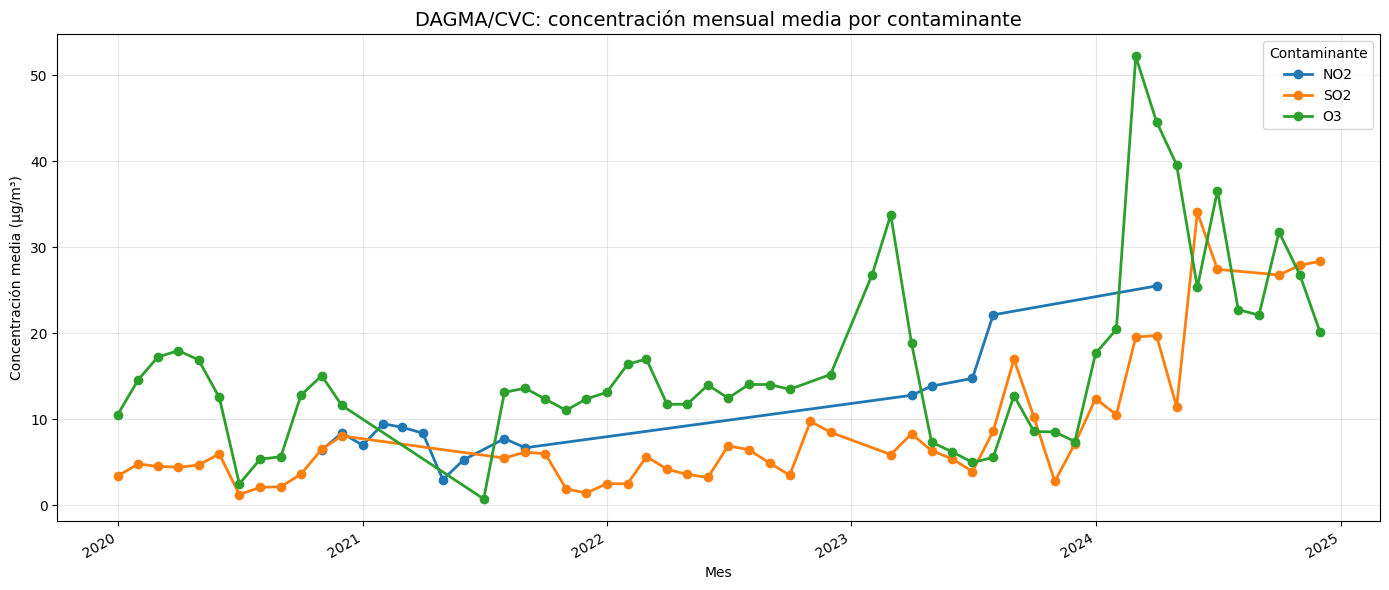

Figura guardada: /home/yeigen/Documents/proyecto-3/docs/evidencias/situacion-1/eda/dagma/dagma_serie_temporal_media_contaminantes.png


In [20]:
OUT_FIG_SIT1 = RAIZ / "docs" / "evidencias" / "situacion-1" / "eda" / "dagma"
OUT_FIG_SIT1.mkdir(parents=True, exist_ok=True)

serie_mensual_global = pq[pq["msfl_code"].isin(CONTAMINANTES)].copy()
serie_mensual_global["mes"] = pd.to_datetime(serie_mensual_global["med_fecha_inicio"]).dt.to_period("M").dt.to_timestamp()
serie_mensual_global = (
    serie_mensual_global
    .groupby(["mes", "msfl_code"], as_index=False)
    .agg(
        concentracion_media=("med_concentracion_estandar", "mean"),
        mediciones=("med_concentracion_estandar", "size"),
        estaciones=("nombre_est", "nunique"),
    )
)

print("Resumen mensual global por contaminante")
print(
    serie_mensual_global
    .groupby("msfl_code")
    .agg(
        meses=("mes", "nunique"),
        mediciones=("mediciones", "sum"),
        estaciones_promedio=("estaciones", "mean"),
        concentracion_media=("concentracion_media", "mean"),
        concentracion_min=("concentracion_media", "min"),
        concentracion_max=("concentracion_media", "max"),
    )
    .round(2)
    .to_string()
)

fig, ax = plt.subplots(figsize=(14, 6))
for contaminante in CONTAMINANTES:
    datos = serie_mensual_global[serie_mensual_global["msfl_code"] == contaminante].sort_values("mes")
    ax.plot(datos["mes"], datos["concentracion_media"], marker="o", linewidth=2, label=contaminante)

ax.set_title("DAGMA/CVC: concentración mensual media por contaminante", fontsize=14)
ax.set_xlabel("Mes")
ax.set_ylabel("Concentración media (µg/m³)")
ax.grid(True, alpha=0.3)
ax.legend(title="Contaminante")
fig.autofmt_xdate()
fig.tight_layout()

ruta_serie_global = OUT_FIG_SIT1 / "dagma_serie_temporal_media_contaminantes.png"
fig.savefig(ruta_serie_global, dpi=180, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {ruta_serie_global}")

Resumen mensual por estación y contaminante
                                 meses  mediciones  concentracion_media
msfl_code nombre_est                                                   
NO2       ESTACIÓN YUMBO            15        6246                10.71
O3        BASE AÉREA                24        7310                 6.38
          COMPARTIR                 24        7507                12.69
          ERA OBRERO                20        6939                 9.45
          ESTACIÓN YUMBO            35       16091                17.56
          LA FLORA                  17        5902                14.02
          PANCE                     21        5861                18.13
          TRANSITORIA-NAVARRO       11        4138                18.81
          UNIVERSIDAD DEL VALLE     25        6350                11.07
SO2       BASE AÉREA                22        7770                 5.75
          CAÑAVERALEJO              16        5053                 0.89
          ESTACIÓN Y

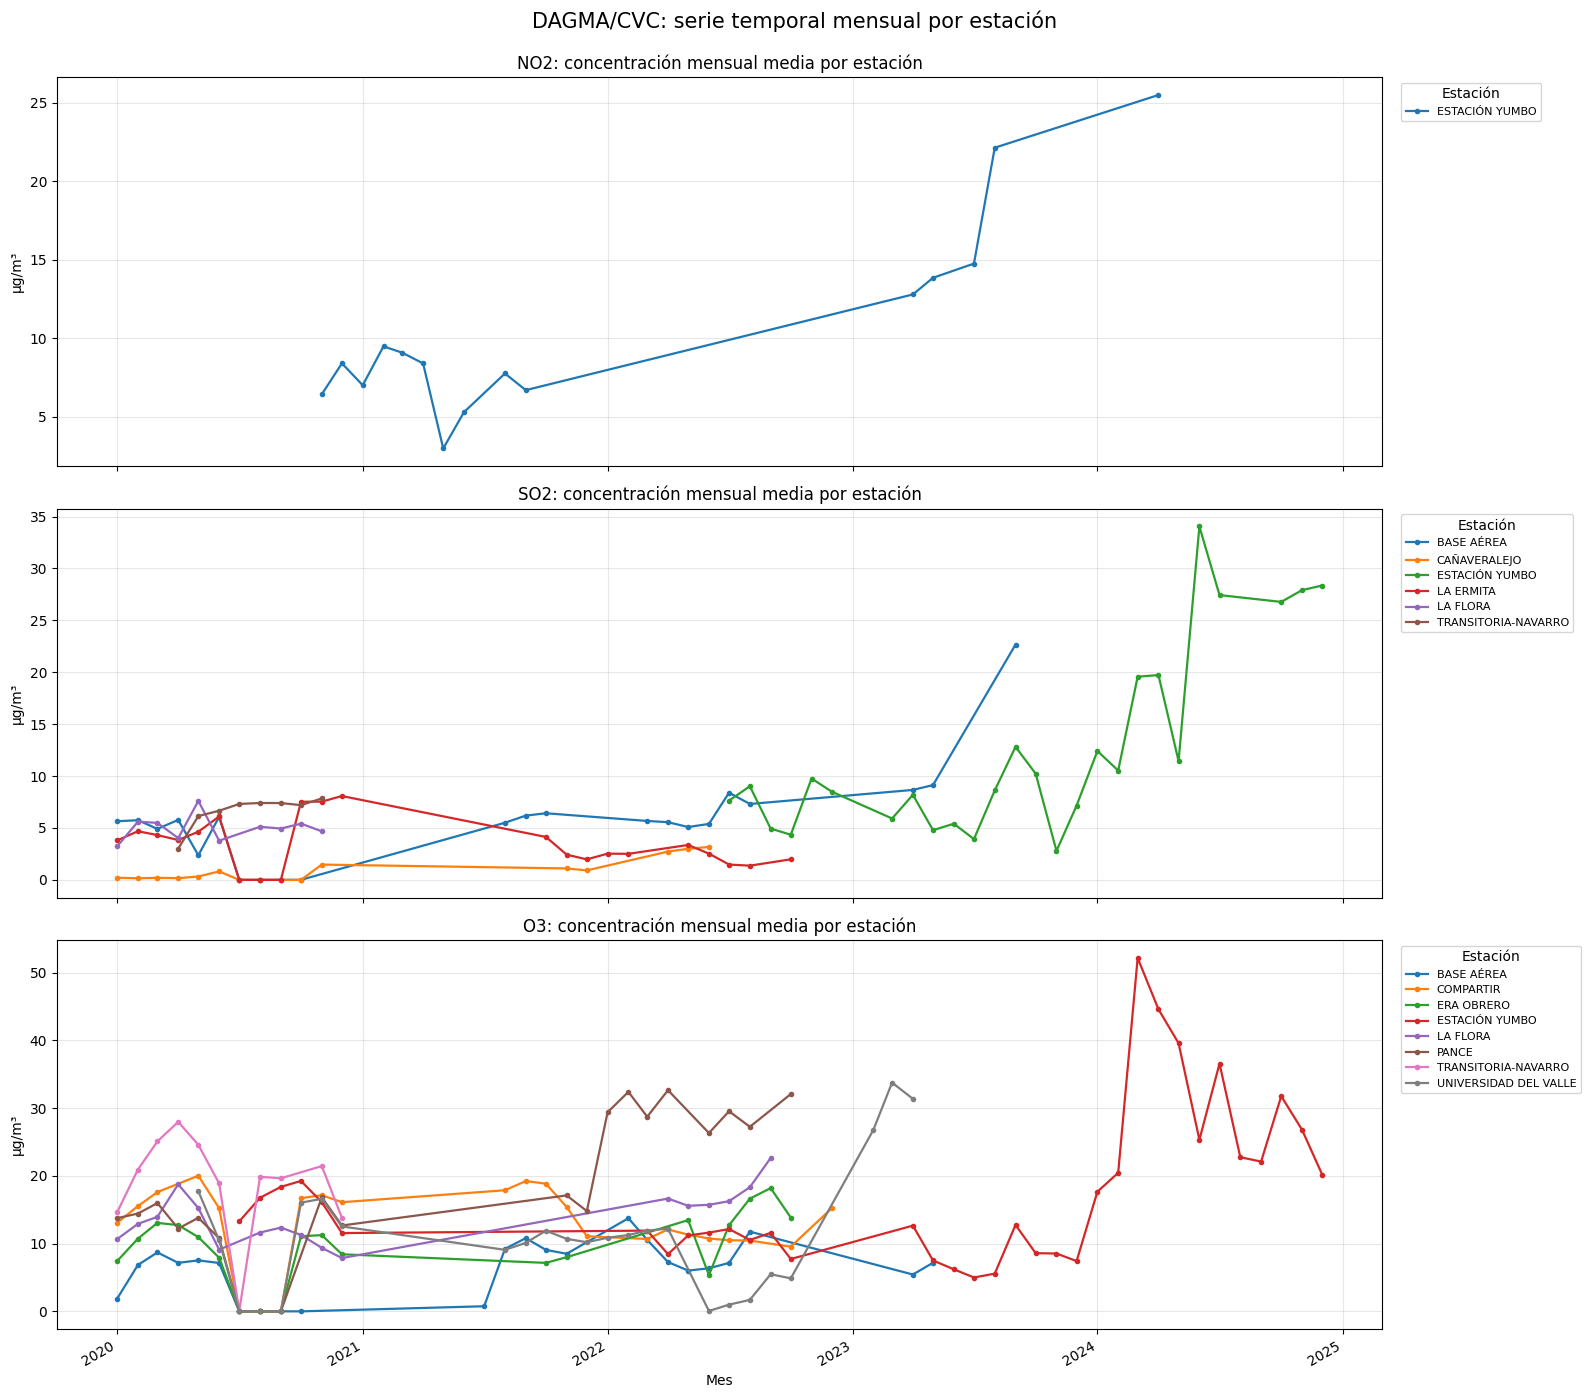

Figura guardada: /home/yeigen/Documents/proyecto-3/docs/evidencias/situacion-1/eda/dagma/dagma_serie_temporal_media_por_estacion.png


In [ ]:
serie_mensual_estacion = pq[pq["msfl_code"].isin(CONTAMINANTES)].copy()
serie_mensual_estacion["mes"] = pd.to_datetime(serie_mensual_estacion["med_fecha_inicio"]).dt.to_period("M").dt.to_timestamp()
serie_mensual_estacion = (
    serie_mensual_estacion
    .groupby(["mes", "nombre_est", "msfl_code"], as_index=False)
    .agg(
        concentracion_media=("med_concentracion_estandar", "mean"),
        mediciones=("med_concentracion_estandar", "size"),
    )
)

print("Resumen mensual por estación y contaminante")
print(
    serie_mensual_estacion
    .groupby(["msfl_code", "nombre_est"])
    .agg(
        meses=("mes", "nunique"),
        mediciones=("mediciones", "sum"),
        concentracion_media=("concentracion_media", "mean"),
    )
    .round(2)
    .sort_index()
    .to_string()
)

fig, axes = plt.subplots(len(CONTAMINANTES), 1, figsize=(16, 14), sharex=True)
for ax, contaminante in zip(axes, CONTAMINANTES):
    datos_contaminante = serie_mensual_estacion[serie_mensual_estacion["msfl_code"] == contaminante]
    for estacion, datos_estacion in datos_contaminante.groupby("nombre_est"):
        datos_estacion = datos_estacion.sort_values("mes")
        ax.plot(datos_estacion["mes"], datos_estacion["concentracion_media"], linewidth=1.6, marker="o", markersize=3, label=estacion)
    ax.set_title(f"{contaminante}: concentración mensual media por estación")
    ax.set_ylabel("µg/m³")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8, title="Estación")

axes[-1].set_xlabel("Mes")
fig.suptitle("DAGMA/CVC: serie temporal mensual por estación", fontsize=15, y=0.995)
fig.autofmt_xdate()
fig.tight_layout()


ruta_serie_estacion = OUT_FIG_SIT1 / "dagma_serie_temporal_media_por_estacion.png"
fig.savefig(ruta_serie_estacion, dpi=180, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {ruta_serie_estacion}")